# SkillLens AI — PCA Visualization

**Stage 6, Part B of the SkillLens AI project.**

## Objective

This notebook uses Principal Component Analysis (PCA) purely for **dimensionality reduction and visualization** — compressing the 9 skill features into 2 dimensions so the student population can be plotted and looked at directly. PCA does **not** create the `skill_category` labels (K-Means already did that in Stage 4), does **not** feed the Random Forest classifier, and does **not** prove anything about real career categories.

**Rules followed in this notebook:**
- Only `student_data.csv` is loaded. `generation_reference.csv` is never used.
- The Stage 3 train/test split is recreated exactly (`test_size=0.2`, `random_state=42`).
- The existing `scaler.pkl` (Stage 3) is loaded and only used to `.transform()` — never refit.
- PCA is fit **only** on `X_train_scaled`. If test observations are shown, they are projected using `pca.transform(X_test_scaled)` — PCA is never fit on test data.
- Where the K-Means-derived `skill_category` is used to color a plot, it is explicitly labeled as a pseudo-category for visual reference only — never presented as something PCA discovered or proved.

## 1. Imports

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load Data

In [2]:
data = pd.read_csv("../data/raw/student_data.csv")
print("Dataset loaded:", data.shape)

Dataset loaded: (300, 10)


## 3. Define Features

In [3]:
features = [
    "cgpa", "coding_skill", "dsa_skill", "math_aptitude", "communication_skill",
    "security_knowledge", "projects_count", "internships_count", "certifications_count",
]

X = data[features]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (300, 9)


## 4. Reproduce the Exact Stage 3 Split

In [4]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (240, 9)
X_test shape:  (60, 9)


## 5. Load the Existing Scaler and Prepare Scaled Data

We load `scaler.pkl` from Stage 3 and only use it to `.transform()` — it is never refit.

In [5]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print("Loaded Stage 3 scaler (not refit).")

Loaded Stage 3 scaler (not refit).


## 6. What Is PCA?

**Principal Component Analysis (PCA)** finds new axes — called **principal components** — that summarize a dataset's variation as efficiently as possible. Each principal component is a specific weighted combination of the original 9 features (e.g., "a bit of coding_skill, a bit of dsa_skill, minus a bit of communication_skill..."), chosen so that:

- **PC1** captures the single direction along which the data varies the *most*.
- **PC2** captures the next-most direction of variation, at a right angle (uncorrelated) to PC1.
- ...and so on for as many components as there are original features.

**Why dimensionality reduction is useful:** humans can't visually inspect a 9-dimensional scatter plot. By keeping only the first 2 principal components — the ones that capture the most variation — we get a 2D picture that preserves as much of the original structure as reasonably possible, so we can actually look at it.

**Principal components vs. original features:** an original feature like `coding_skill` has a direct, obvious meaning. A principal component does not — it's a mathematical combination of several original features at once, chosen purely to maximize captured variation. This trade-off (losing direct interpretability in exchange for a visualizable summary) is why PCA is used here only for visualization, never as an input to the classifier or the career alignment engine.

## 7. Fit PCA with All 9 Components (to Inspect Explained Variance)

We first fit PCA keeping all 9 components — this doesn't lose any information, it just re-expresses the same data on new axes. This lets us see how much variation each component captures before deciding to keep only 2 for visualization. Fit **only** on `X_train_scaled`.

In [6]:
pca_full = PCA(n_components=9, random_state=42)
pca_full.fit(X_train_scaled)

explained_variance_table = pd.DataFrame({
    "component": [f"PC{i}" for i in range(1, 10)],
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_),
})
explained_variance_table.round(4)

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.4689,0.4689
1,PC2,0.1146,0.5835
2,PC3,0.1010,0.6845
3,PC4,0.0905,0.7750
4,PC5,0.0670,0.8420
5,PC6,0.0523,0.8943
6,PC7,0.0436,0.9379
7,PC8,0.0345,0.9724
8,PC9,0.0276,1.0000


## 8. Explained-Variance Plot

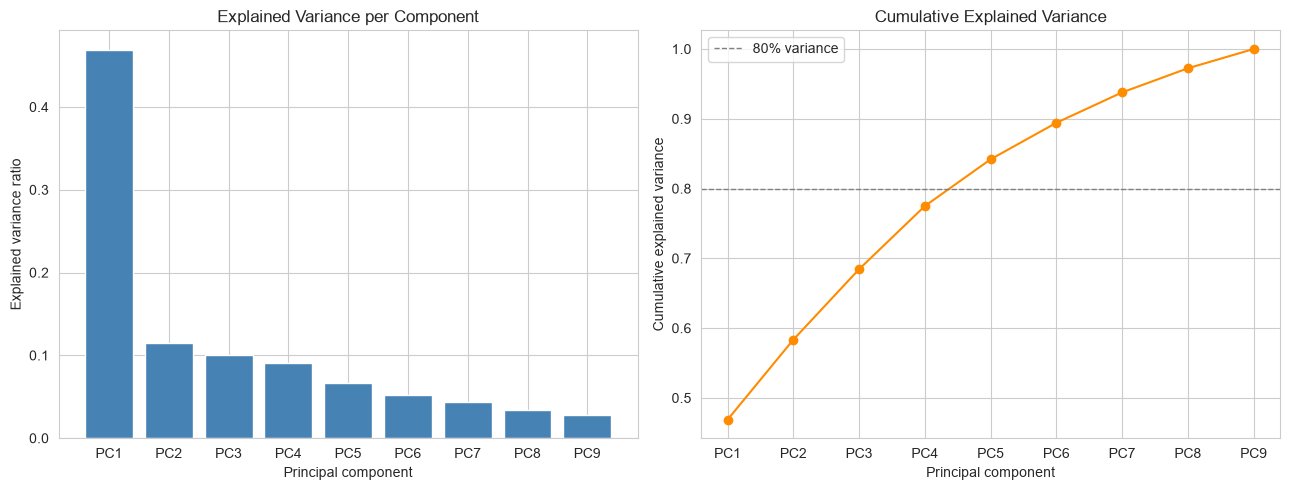

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(explained_variance_table["component"], explained_variance_table["explained_variance_ratio"], color="steelblue")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(explained_variance_table["component"], explained_variance_table["cumulative_explained_variance"], marker="o", color="darkorange")
axes[1].axhline(0.8, color="gray", linestyle="--", linewidth=1, label="80% variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the numbers:** PC1 alone explains about 46.9% of the total variance in the 9 features — a large single component, which lines up with Stage 2 EDA's finding that `coding_skill`, `dsa_skill`, `math_aptitude`, and `projects_count` are all moderately-to-strongly correlated (PCA is effectively compressing that shared "technical strength" signal into one axis). PC2 adds another 11.5%, so PC1+PC2 together explain about 58.3% of total variance. Reaching 80% cumulative variance takes about 5 components. This means our 2D visualization below captures a majority, but not all, of the original structure — a reasonable summary, not a complete picture.

## 9. Fit the 2-Component PCA for Visualization

We fit a fresh `PCA(n_components=2)` on `X_train_scaled` only, then use it to transform both the training data and, separately, the test data via `pca.transform(X_test_scaled)` — the test data is never used to fit PCA.

In [8]:
pca_2d = PCA(n_components=2, random_state=42)
train_pca = pca_2d.fit_transform(X_train_scaled)     # fit + transform on training data
test_pca = pca_2d.transform(X_test_scaled)            # transform only - never fit on test data

pc1_variance = pca_2d.explained_variance_ratio_[0]
pc2_variance = pca_2d.explained_variance_ratio_[1]
cumulative_variance = pc1_variance + pc2_variance

print(f"Variance explained by PC1: {pc1_variance:.4f} ({pc1_variance*100:.1f}%)")
print(f"Variance explained by PC2: {pc2_variance:.4f} ({pc2_variance*100:.1f}%)")
print(f"Cumulative variance explained by PC1 + PC2: {cumulative_variance:.4f} ({cumulative_variance*100:.1f}%)")

Variance explained by PC1: 0.4689 (46.9%)
Variance explained by PC2: 0.1146 (11.5%)
Cumulative variance explained by PC1 + PC2: 0.5835 (58.4%)


## 10. Load Existing K-Means Categories (Optional Visualization Aid Only)

To make the scatter plot more informative, we optionally color points by the `skill_category` pseudo-category already produced by Stage 4's K-Means model. We only `.predict()` with the already-fitted model (never refit) — this is the same, already-existing model and mapping, reused here purely so the plot has something meaningful to color by.

**This coloring does not mean PCA created these categories.** The categories come entirely from K-Means (Stage 4); PCA is only providing the 2D coordinates points are plotted at.

In [9]:
kmeans_model = joblib.load("../models/kmeans_model.pkl")

with open("../models/cluster_category_mapping.json") as f:
    cluster_to_category = {int(cluster_id): name for cluster_id, name in json.load(f).items()}

# .predict() only - the K-Means model is already fitted (Stage 4) and is not refit here.
train_skill_category = pd.Series(kmeans_model.predict(X_train_scaled), index=X_train.index).map(cluster_to_category)

print("skill_category counts (training data, for plot coloring only):")
print(train_skill_category.value_counts())

skill_category counts (training data, for plot coloring only):
Needs Improvement    81
Strong Overall       56
Strong Technical     54
Balanced             49
Name: count, dtype: int64


## 11. 2D PCA Scatter Plot — Colored by K-Means Pseudo-Category

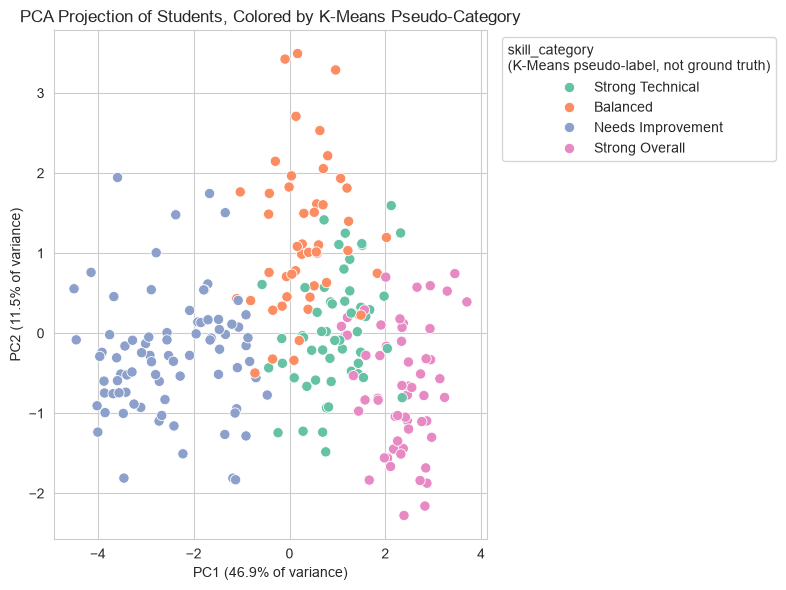

In [10]:
plot_df = pd.DataFrame(train_pca, columns=["PC1", "PC2"])
plot_df["skill_category (K-Means pseudo-category)"] = train_skill_category.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2",
    hue="skill_category (K-Means pseudo-category)", palette="Set2", s=55,
)
plt.title("PCA Projection of Students, Colored by K-Means Pseudo-Category")
plt.xlabel(f"PC1 ({pc1_variance*100:.1f}% of variance)")
plt.ylabel(f"PC2 ({pc2_variance*100:.1f}% of variance)")
plt.legend(title="skill_category\n(K-Means pseudo-label, not ground truth)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12. 2D PCA Scatter Plot — Without Category Labels

The same projection, shown plain. This is useful to see the raw shape of the data without any labeling influencing how we read it — a good check on whether the colored version above is showing real structure or just imposing color on what is otherwise a fairly continuous blob.

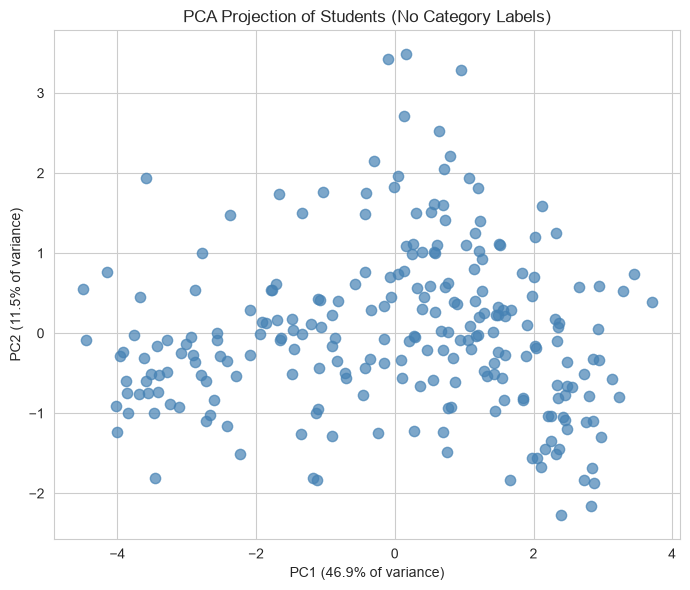

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(plot_df["PC1"], plot_df["PC2"], s=55, alpha=0.7, color="steelblue")
plt.title("PCA Projection of Students (No Category Labels)")
plt.xlabel(f"PC1 ({pc1_variance*100:.1f}% of variance)")
plt.ylabel(f"PC2 ({pc2_variance*100:.1f}% of variance)")
plt.tight_layout()
plt.show()

In [12]:
pca_loadings = pd.DataFrame(pca_2d.components_.T, index=features, columns=["PC1", "PC2"])
pca_loadings.round(3)

,PC1,PC2
cgpa,0.311,-0.254
coding_skill,0.410,-0.066
dsa_skill,0.393,-0.124
math_aptitude,0.377,-0.195
communication_skill,0.204,-0.517
security_knowledge,0.287,0.470
projects_count,0.414,0.010
internships_count,0.185,0.559
certifications_count,0.330,0.276


## 13. What the Plot Suggests

To understand the axes honestly (not just by eyeballing the scatter), we look at each principal component's **loadings** — how much each original feature contributes to it:

| Feature | PC1 | PC2 |
|---|---|---|
| cgpa | 0.311 | -0.254 |
| coding_skill | 0.410 | -0.066 |
| dsa_skill | 0.393 | -0.124 |
| math_aptitude | 0.377 | -0.195 |
| communication_skill | 0.204 | **-0.517** |
| security_knowledge | 0.287 | **0.470** |
| projects_count | **0.414** | 0.010 |
| internships_count | 0.185 | **0.559** |
| certifications_count | 0.330 | 0.276 |

**PC1** loads positively on *every* feature, most heavily on `projects_count`, `coding_skill`, and `dsa_skill`. This means PC1 is roughly a "general skill strength" axis — students further right on the plot tend to score higher across the board, especially technically. This lines up with Stage 4: the "Needs Improvement" cluster should sit toward low PC1, while "Strong Technical" and "Strong Overall" should sit toward high PC1.

**PC2** contrasts two things: strongly negative for `communication_skill` (and somewhat `cgpa`, `math_aptitude`), strongly positive for `internships_count` and `security_knowledge`. So PC2 roughly separates students who lean toward communication/academic strength (low PC2) from students who lean toward security-knowledge/internship-heavy profiles (high PC2). This lines up with Stage 4's "Strong Overall" cluster (high communication) sitting toward low PC2, and "Balanced" (high security knowledge) sitting toward high PC2.

**What this suggests, without overclaiming:** the colored plot's rough grouping by `skill_category` is consistent with genuine, interpretable patterns in the underlying features (via the loadings above) — it is not an arbitrary coloring of a random cloud. However, this is a 2D summary capturing only ~58% of total variance, categories visibly overlap at their edges (matching the modest silhouette scores from Stage 4), and none of this is evidence about real-world career readiness — it only describes structure in this synthetic dataset's 9 measured features.

## 14. Limitations

- **PC1 and PC2 together explain only ~58% of total variance** — a majority, but the remaining ~42% (spread across 7 more components) is not shown in this 2D plot. Some real structure is necessarily lost.
- **Principal components are not directly interpretable features.** "PC1" isn't a skill a student has — it's a mathematical combination, useful for visualization but not for the career alignment engine, which deliberately uses the original, directly meaningful 9 features instead.
- **The dataset is synthetic**, so the patterns PCA reveals describe our archetype-based generator's structure, not verified real-world student data.
- **Coloring by `skill_category` in Section 11 visually reinforces Stage 4's clustering, but does not independently validate it.** PCA and K-Means were both computed from the same 9 features, so agreement between "the plot looks grouped" and "K-Means found 4 groups" is expected, not an independent confirmation from a different source of truth.
- **This is not evidence of career readiness or real-world category membership.** It is a description of variance structure in 9 measured, synthetic skill features.

## 15. Save the 2-Component PCA Model

Unlike DBSCAN, PCA has a genuine `.transform()` method for new data, so saving it is actually useful — a future feature (e.g. an "Analysis" page showing a new student's position on this plot relative to others) could reuse it without refitting. We save only the 2-component PCA model and a small metadata file — nothing else from this notebook is needed later.

In [13]:
joblib.dump(pca_2d, "../models/pca_model.pkl")

pca_info = {
    "n_components": 2,
    "fitted_on": "X_train_scaled (Stage 3 split, Stage 3 scaler)",
    "feature_list": features,
    "explained_variance_ratio": {
        "PC1": round(float(pc1_variance), 4),
        "PC2": round(float(pc2_variance), 4),
    },
    "cumulative_explained_variance_pc1_pc2": round(float(cumulative_variance), 4),
    "note": (
        "This PCA model is for visualization/dimensionality reduction only. "
        "It is not used by the classifier or the career alignment engine, and "
        "it does not represent or prove real-world career categories."
    ),
}

with open("../models/pca_info.json", "w") as f:
    json.dump(pca_info, f, indent=2)

print("Saved ml/models/pca_model.pkl")
print("Saved ml/models/pca_info.json")
print()
print(json.dumps(pca_info, indent=2))

Saved ml/models/pca_model.pkl
Saved ml/models/pca_info.json

{
  "n_components": 2,
  "fitted_on": "X_train_scaled (Stage 3 split, Stage 3 scaler)",
  "feature_list": [
    "cgpa",
    "coding_skill",
    "dsa_skill",
    "math_aptitude",
    "communication_skill",
    "security_knowledge",
    "projects_count",
    "internships_count",
    "certifications_count"
  ],
  "explained_variance_ratio": {
    "PC1": 0.4689,
    "PC2": 0.1146
  },
  "cumulative_explained_variance_pc1_pc2": 0.5835,
  "note": "This PCA model is for visualization/dimensionality reduction only. It is not used by the classifier or the career alignment engine, and it does not represent or prove real-world career categories."
}


## 16. Conclusion

PCA was fit only on `X_train_scaled`, following the same leakage-safe pattern as every previous stage. PC1 explains ~46.9% of total variance (a general "skill strength" axis, dominated by projects/coding/DSA), PC2 adds ~11.5% (contrasting communication/academic strength against security-knowledge/internship-heavy profiles), for a combined ~58.3% captured in the 2D visualization.

The 2D plot, optionally colored by Stage 4's K-Means `skill_category` pseudo-categories, shows a pattern that is consistent with genuine, loading-supported structure in the data — not proof of real-world career categories, employability, or career readiness. PCA here is strictly a visualization and dimensionality-reduction tool; it does not feed the Random Forest classifier or the career alignment engine, and it does not replace or validate K-Means.

`ml/models/pca_model.pkl` and `ml/models/pca_info.json` are saved because PCA's `.transform()` method makes it genuinely reusable later (e.g. plotting a new student's position). No other files from this notebook are saved. `scaler.pkl`, `kmeans_model.pkl`, and `skill_category_classifier.pkl` were only loaded and used via `.transform()`/`.predict()` — never refit or modified.